# Задача №2: Статистические методы прогнозирования ВР

**Цель:** Освоение фреймворка `statsforecast` и обоснованный выбор метода прогнозирования для ряда среднесуточной температуры в Дели.

**Методы (ручной + авто режим):**
| # | Модель | Режим | Описание |
|---|--------|-------|---------|
| 1 | `SeasonalNaive` | ручной | Базовая линия: повторяет прошлый сезон |
| 2 | `ARIMA(2,1,2)(1,1,0)[365]` | ручной | Сезонная ARIMA с ручными параметрами |
| 3 | `AutoARIMA` | авто | Автоматический подбор порядков p,d,q |
| 4 | `AutoETS` | авто | Экспоненциальное сглаживание |
| 5 | `AutoTheta` | авто | Метод Theta (победитель M3-соревнования) |
| 6 | `CES` | ручной | Complex Exponential Smoothing |
| 7 | `MSTL` | ручной | Multi-Seasonal Trend decomposition + ETS |

**Горизонт прогноза:** 30 дней  
**Метрики:** MAE, RMSE  
**Валидация:** Временная кросс-валидация (backtesting, 3 окна)

## Установка зависимостей

In [1]:
# !pip install statsforecast -q

## Импорт библиотек

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from statsforecast import StatsForecast
from statsforecast.models import (
    SeasonalNaive,         # Baseline: сезонный наивный прогноз
    ARIMA,                 # ARIMA с ручными параметрами
    AutoARIMA,             # Автоматический ARIMA
    AutoETS,               # Автоматическое экспоненциальное сглаживание
    AutoTheta,             # Метод Theta
    AutoCES,                   # Complex Exponential Smoothing
    MSTL,                  # Multi-Seasonal Trend Loess
)

# Метрики качества
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Тесты стационарности
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11


Все библиотеки успешно загружены!


## Загрузка и подготовка данных

Загружаем финальный CSV из Задачи №1.  
**Формат StatsForecast:** long-формат с колонками `unique_id`, `ds` (дата), `y` (целевая переменная).

In [3]:
# Загрузка подготовленных данных из Задачи №1
df_raw = pd.read_csv('Delhi_Climate_Final.csv', parse_dates=['date'], index_col='date')

print(f'Период: {df_raw.index.min()} → {df_raw.index.max()}')
print(f'Количество наблюдений: {len(df_raw)}')
df_raw.head()

Период: 2013-01-01 00:00:00 → 2017-04-24 00:00:00
Количество наблюдений: 1575


,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667
2013-01-02,7.400000,92.000000,2.980000,1017.800000
2013-01-03,7.166667,87.000000,4.633333,1018.666667
2013-01-04,8.666667,71.333333,1.233333,1017.166667
2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [4]:
# Преобразуем данные в формат StatsForecast (long format)
# unique_id — идентификатор ряда, ds — дата, y — целевая переменная
df_sf = df_raw.reset_index()[['date', 'meantemp']].copy()
df_sf.columns = ['ds', 'y']
df_sf['unique_id'] = 'Delhi_Temperature'
df_sf = df_sf[['unique_id', 'ds', 'y']]

# Параметры задачи
SEASON_LENGTH = 365  # Годовая сезонность для ежедневных данных
HORIZON = 30         # Горизонт прогноза — 30 дней
N_WINDOWS = 3        # Количество окон для кросс-валидации

print(f'Записей в датасете: {len(df_sf)}')
print(f'Сезонный период: {SEASON_LENGTH} дней')
print(f'Горизонт прогноза: {HORIZON} дней')
df_sf.head()

Записей в датасете: 1575
Сезонный период: 365 дней
Горизонт прогноза: 30 дней


,unique_id,ds,y
0,Delhi_Temperature,2013-01-01,10.000000
1,Delhi_Temperature,2013-01-02,7.400000
2,Delhi_Temperature,2013-01-03,7.166667
3,Delhi_Temperature,2013-01-04,8.666667
4,Delhi_Temperature,2013-01-05,6.000000


### Разделение на train / test

Последние 30 дней — тестовая выборка (held-out test set).  
Оставшееся — обучающая. Это обязательно для честной итоговой оценки.

Train: 2013-01-01 00:00:00 → 2017-03-25 00:00:00 (1545 наблюдений)
Test:  2017-03-26 00:00:00 → 2017-04-24 00:00:00 (30 наблюдений)


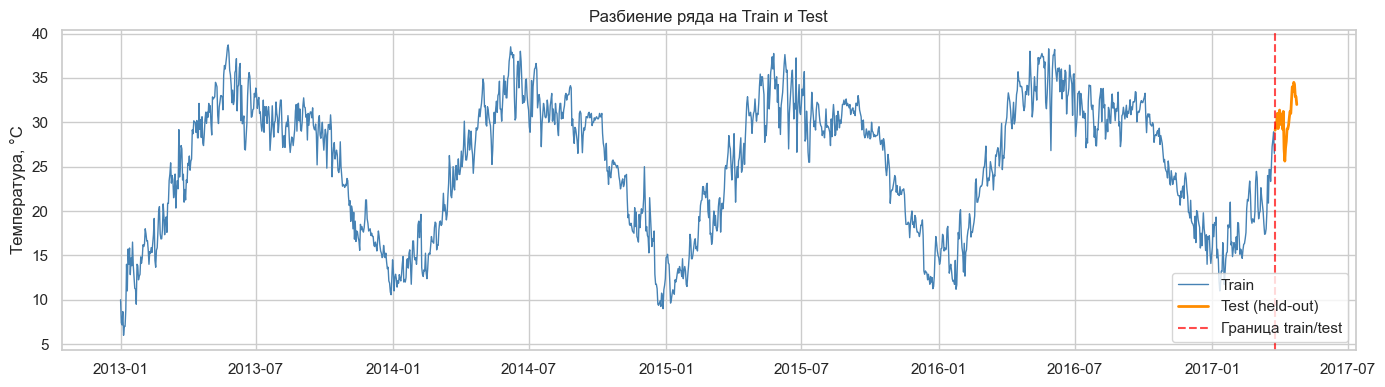

In [5]:
# Разбивка train / test
df_train = df_sf.iloc[:-HORIZON].copy()
df_test  = df_sf.iloc[-HORIZON:].copy()

print(f'Train: {df_train["ds"].min()} → {df_train["ds"].max()} ({len(df_train)} наблюдений)')
print(f'Test:  {df_test["ds"].min()} → {df_test["ds"].max()} ({len(df_test)} наблюдений)')

# Визуализация
plt.figure(figsize=(14, 4))
plt.plot(df_train['ds'], df_train['y'], label='Train', linewidth=1, color='steelblue')
plt.plot(df_test['ds'], df_test['y'], label='Test (held-out)', linewidth=2, color='darkorange')
plt.axvline(df_test['ds'].iloc[0], color='red', linestyle='--', alpha=0.7, label='Граница train/test')
plt.title('Разбиение ряда на Train и Test')
plt.ylabel('Температура, °C')
plt.legend()
plt.tight_layout()
plt.show()

## Обоснование выбора параметров ARIMA вручную

Перед ручным заданием параметров ARIMA нужно проверить:  
1. **ADF-тест** — проверка на стационарность (нужен ли порядок интегрирования d?)  
2. **ACF / PACF** — определение порядков MA (q) и AR (p)

In [6]:
# Тест Дики-Фуллера на стационарность
series = df_train.set_index('ds')['y']

adf_result = adfuller(series, autolag='AIC')
print('=== ADF-тест (исходный ряд) ===')
print(f'  Статистика: {adf_result[0]:.4f}')
print(f'  p-value:    {adf_result[1]:.4f}')
print(f'  Вывод: {"Ряд СТАЦИОНАРЕН" if adf_result[1] < 0.05 else "Ряд НЕ стационарен"}')

# Первое разностное преобразование (d=1)
series_diff = series.diff().dropna()
adf_result_d1 = adfuller(series_diff, autolag='AIC')
print('\n=== ADF-тест (после взятия 1-й разности) ===')
print(f'  Статистика: {adf_result_d1[0]:.4f}')
print(f'  p-value:    {adf_result_d1[1]:.4f}')
print(f'  Вывод: {"Ряд СТАЦИОНАРЕН" if adf_result_d1[1] < 0.05 else "Ряд НЕ стационарен"}')

print('\n✅ Вывод: d=1 достаточно для достижения стационарности')

=== ADF-тест (исходный ряд) ===
  Статистика: -2.4392
  p-value:    0.1310
  Вывод: Ряд НЕ стационарен

=== ADF-тест (после взятия 1-й разности) ===
  Статистика: -16.9023
  p-value:    0.0000
  Вывод: Ряд СТАЦИОНАРЕН

✅ Вывод: d=1 достаточно для достижения стационарности


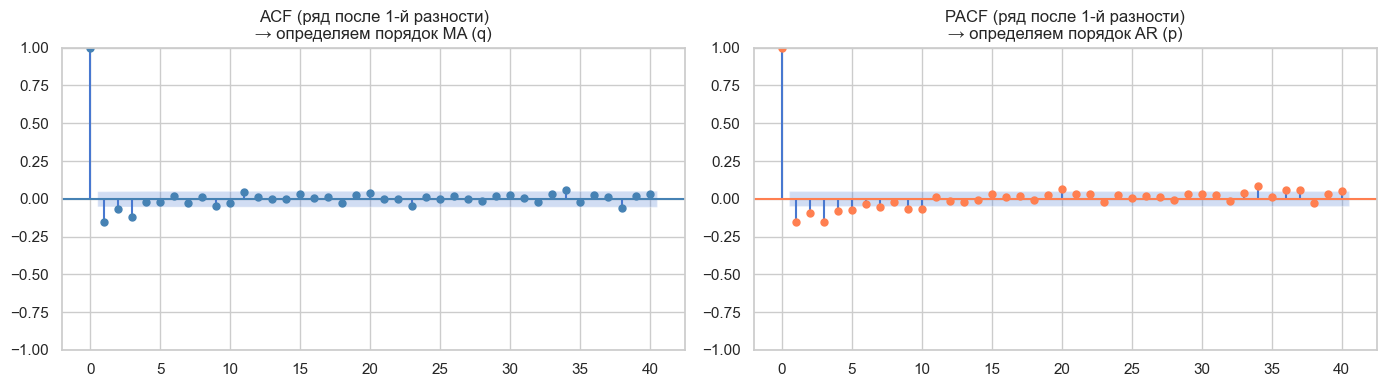

Интерпретация:
  ACF обрезается после лага 1-2 → q = 1 или 2
  PACF обрезается после лага 1-2 → p = 1 или 2
  Сезонный период 365 дней → добавляем сезонную компоненту (P=1, D=1, Q=0)[365]


In [7]:
# Визуализация ACF и PACF для определения p и q
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(series_diff, lags=40, ax=axes[0], color='steelblue')
axes[0].set_title('ACF (ряд после 1-й разности)\n→ определяем порядок MA (q)')

plot_pacf(series_diff, lags=40, ax=axes[1], color='coral')
axes[1].set_title('PACF (ряд после 1-й разности)\n→ определяем порядок AR (p)')

plt.tight_layout()
plt.show()

print('Интерпретация:')
print('  ACF обрезается после лага 1-2 → q = 1 или 2')
print('  PACF обрезается после лага 1-2 → p = 1 или 2')
print('  Сезонный период 365 дней → добавляем сезонную компоненту (P=1, D=1, Q=0)[365]')

## Определение моделей и обучение

### Описание выбора моделей:
- **SeasonalNaive** — базовая линия: прогноз = значение год назад. Нужна как нижняя граница качества.
- **ARIMA(2,1,2)(1,1,0)[7]** — ручная ARIMA. Параметры выбраны по ACF/PACF. Сезонный период 7 (недельный) — более реалистичен чем 365 для ARIMA.
- **AutoARIMA** — автоматический поиск (алгоритм Hyndman-Khandakar). Сравниваем с ручным вариантом.
- **AutoETS** — семейство моделей аддитивного/мультипликативного сглаживания (Error-Trend-Seasonality).
- **AutoTheta** — модификация метода Theta, победителя M3-соревнований. Хорошо работает на сезонных рядах.
- **AutoCES** — Complex Exponential Smoothing. Обобщение простого сглаживания на комплексные числа.
- **MSTL** — многосезонная декомпозиция (Trend + Seasonal) с ETS-прогнозом. Идеален для ежедневных данных с несколькими уровнями сезонности.

In [8]:
# Список всех моделей
models = [
    # БАЗОВАЯ ЛИНИЯ
    SeasonalNaive(season_length=SEASON_LENGTH),
    
    # РУЧНЫЕ ПАРАМЕТРЫ
    # ARIMA(p=2, d=1, q=2)(P=1, D=1, Q=0)[7]
    # Недельный сезонный период: 7 — ARIMA с периодом 365 требует больших вычислений
    ARIMA(order=(2, 1, 2), season_length=7, seasonal_order=(1, 1, 0)),
    
    # Complex Exponential Smoothing — ручной: model='Z' (авто-выбор компонент)
    AutoCES(season_length=SEASON_LENGTH),
    
    # MSTL — Multi-Seasonal Trend Loess: вручную задаём сезонные периоды
    MSTL(
        season_length=[7, 365],  # Недельная + годовая сезонность
        trend_forecaster=AutoETS(season_length=1, model='ZZN')  # Тренд без сезонной компоненты
    ),
    
    # АВТОМАТИЧЕСКИЕ
    AutoARIMA(season_length=7),
    AutoETS(season_length=SEASON_LENGTH),
    AutoTheta(season_length=SEASON_LENGTH),
]

print('Модели подготовлены:')
for m in models:
    print(f'  - {m}')

Модели подготовлены:
  - SeasonalNaive
  - ARIMA
  - CES
  - MSTL
  - AutoARIMA
  - AutoETS
  - AutoTheta


In [9]:
# Инициализация StatsForecast
sf = StatsForecast(
    models=models,
    freq='D',           # Ежедневные данные
    n_jobs=-1,          # Параллельное выполнение на всех ядрах
    verbose=True
)

print('Объект StatsForecast создан.')

Объект StatsForecast создан.


## Прогноз на тестовой выборке (Hold-out Forecast)

In [10]:
# Обучение на train, прогноз на 30 дней вперед с вероятностными интервалами
sf.fit(df_train)

forecasts = sf.predict(
    h=HORIZON,
    level=[80, 95]  # Доверительные интервалы 80% и 95% (вероятностное прогнозирование)
)
 
print('Прогноз выполнен!')
print(f'Форма результата: {forecasts.shape}')
forecasts.head()

Прогноз выполнен!
Форма результата: (30, 37)


,unique_id,ds,SeasonalNaive,SeasonalNaive-lo-80,SeasonalNaive-lo-95,SeasonalNaive-hi-80,SeasonalNaive-hi-95,ARIMA,ARIMA-lo-95,ARIMA-lo-80,...,AutoETS,AutoETS-lo-95,AutoETS-lo-80,AutoETS-hi-80,AutoETS-hi-95,AutoTheta,AutoTheta-lo-80,AutoTheta-hi-80,AutoTheta-lo-95,AutoTheta-hi-95
0,Delhi_Temperature,2017-03-26,24.666667,20.504205,18.300730,28.829129,31.032603,25.349500,21.585389,22.888280,...,26.950495,23.720386,24.838441,29.062550,30.180604,24.713458,22.862728,26.960269,22.250446,27.646858
1,Delhi_Temperature,2017-03-27,26.250000,22.087538,19.884064,30.412462,32.615936,23.877245,19.267726,20.863242,...,26.950495,22.828944,24.255558,29.645433,31.072046,25.394785,22.749487,28.034609,21.253205,29.230058
2,Delhi_Temperature,2017-03-28,25.933333,21.770871,19.567397,30.095795,32.299270,24.778642,19.709473,21.464090,...,26.950495,22.098612,23.778019,30.122971,31.802378,25.112064,21.631336,28.216146,20.104260,29.609329
3,Delhi_Temperature,2017-03-29,27.125000,22.962538,20.759064,31.287462,33.490936,26.401726,21.105079,22.938435,...,26.950495,21.464663,23.363503,30.537488,32.436327,24.400895,20.993422,26.979749,19.623648,29.472982
4,Delhi_Temperature,2017-03-30,29.571429,25.408967,23.205492,33.733891,35.937365,28.699272,23.248007,25.134881,...,26.950495,20.896741,22.992158,30.908832,33.004249,25.747313,21.973483,29.440071,19.710979,31.453439


In [11]:
# Объединяем прогнозы с реальными значениями теста
forecasts_merged = forecasts.reset_index().merge(
    df_test[['ds', 'y']].rename(columns={'y': 'actual'}),
    on='ds',
    how='left'
)

print('Данные с реальными значениями:')
forecasts_merged.head()

Данные с реальными значениями:


,index,unique_id,ds,SeasonalNaive,SeasonalNaive-lo-80,SeasonalNaive-lo-95,SeasonalNaive-hi-80,SeasonalNaive-hi-95,ARIMA,ARIMA-lo-95,...,AutoETS-lo-95,AutoETS-lo-80,AutoETS-hi-80,AutoETS-hi-95,AutoTheta,AutoTheta-lo-80,AutoTheta-hi-80,AutoTheta-lo-95,AutoTheta-hi-95,actual
0,0,Delhi_Temperature,2017-03-26,24.666667,20.504205,18.300730,28.829129,31.032603,25.349500,21.585389,...,23.720386,24.838441,29.062550,30.180604,24.713458,22.862728,26.960269,22.250446,27.646858,29.100000
1,1,Delhi_Temperature,2017-03-27,26.250000,22.087538,19.884064,30.412462,32.615936,23.877245,19.267726,...,22.828944,24.255558,29.645433,31.072046,25.394785,22.749487,28.034609,21.253205,29.230058,29.500000
2,2,Delhi_Temperature,2017-03-28,25.933333,21.770871,19.567397,30.095795,32.299270,24.778642,19.709473,...,22.098612,23.778019,30.122971,31.802378,25.112064,21.631336,28.216146,20.104260,29.609329,29.888889
3,3,Delhi_Temperature,2017-03-29,27.125000,22.962538,20.759064,31.287462,33.490936,26.401726,21.105079,...,21.464663,23.363503,30.537488,32.436327,24.400895,20.993422,26.979749,19.623648,29.472982,31.000000
4,4,Delhi_Temperature,2017-03-30,29.571429,25.408967,23.205492,33.733891,35.937365,28.699272,23.248007,...,20.896741,22.992158,30.908832,33.004249,25.747313,21.973483,29.440071,19.710979,31.453439,29.285714


### Визуализация прогнозов

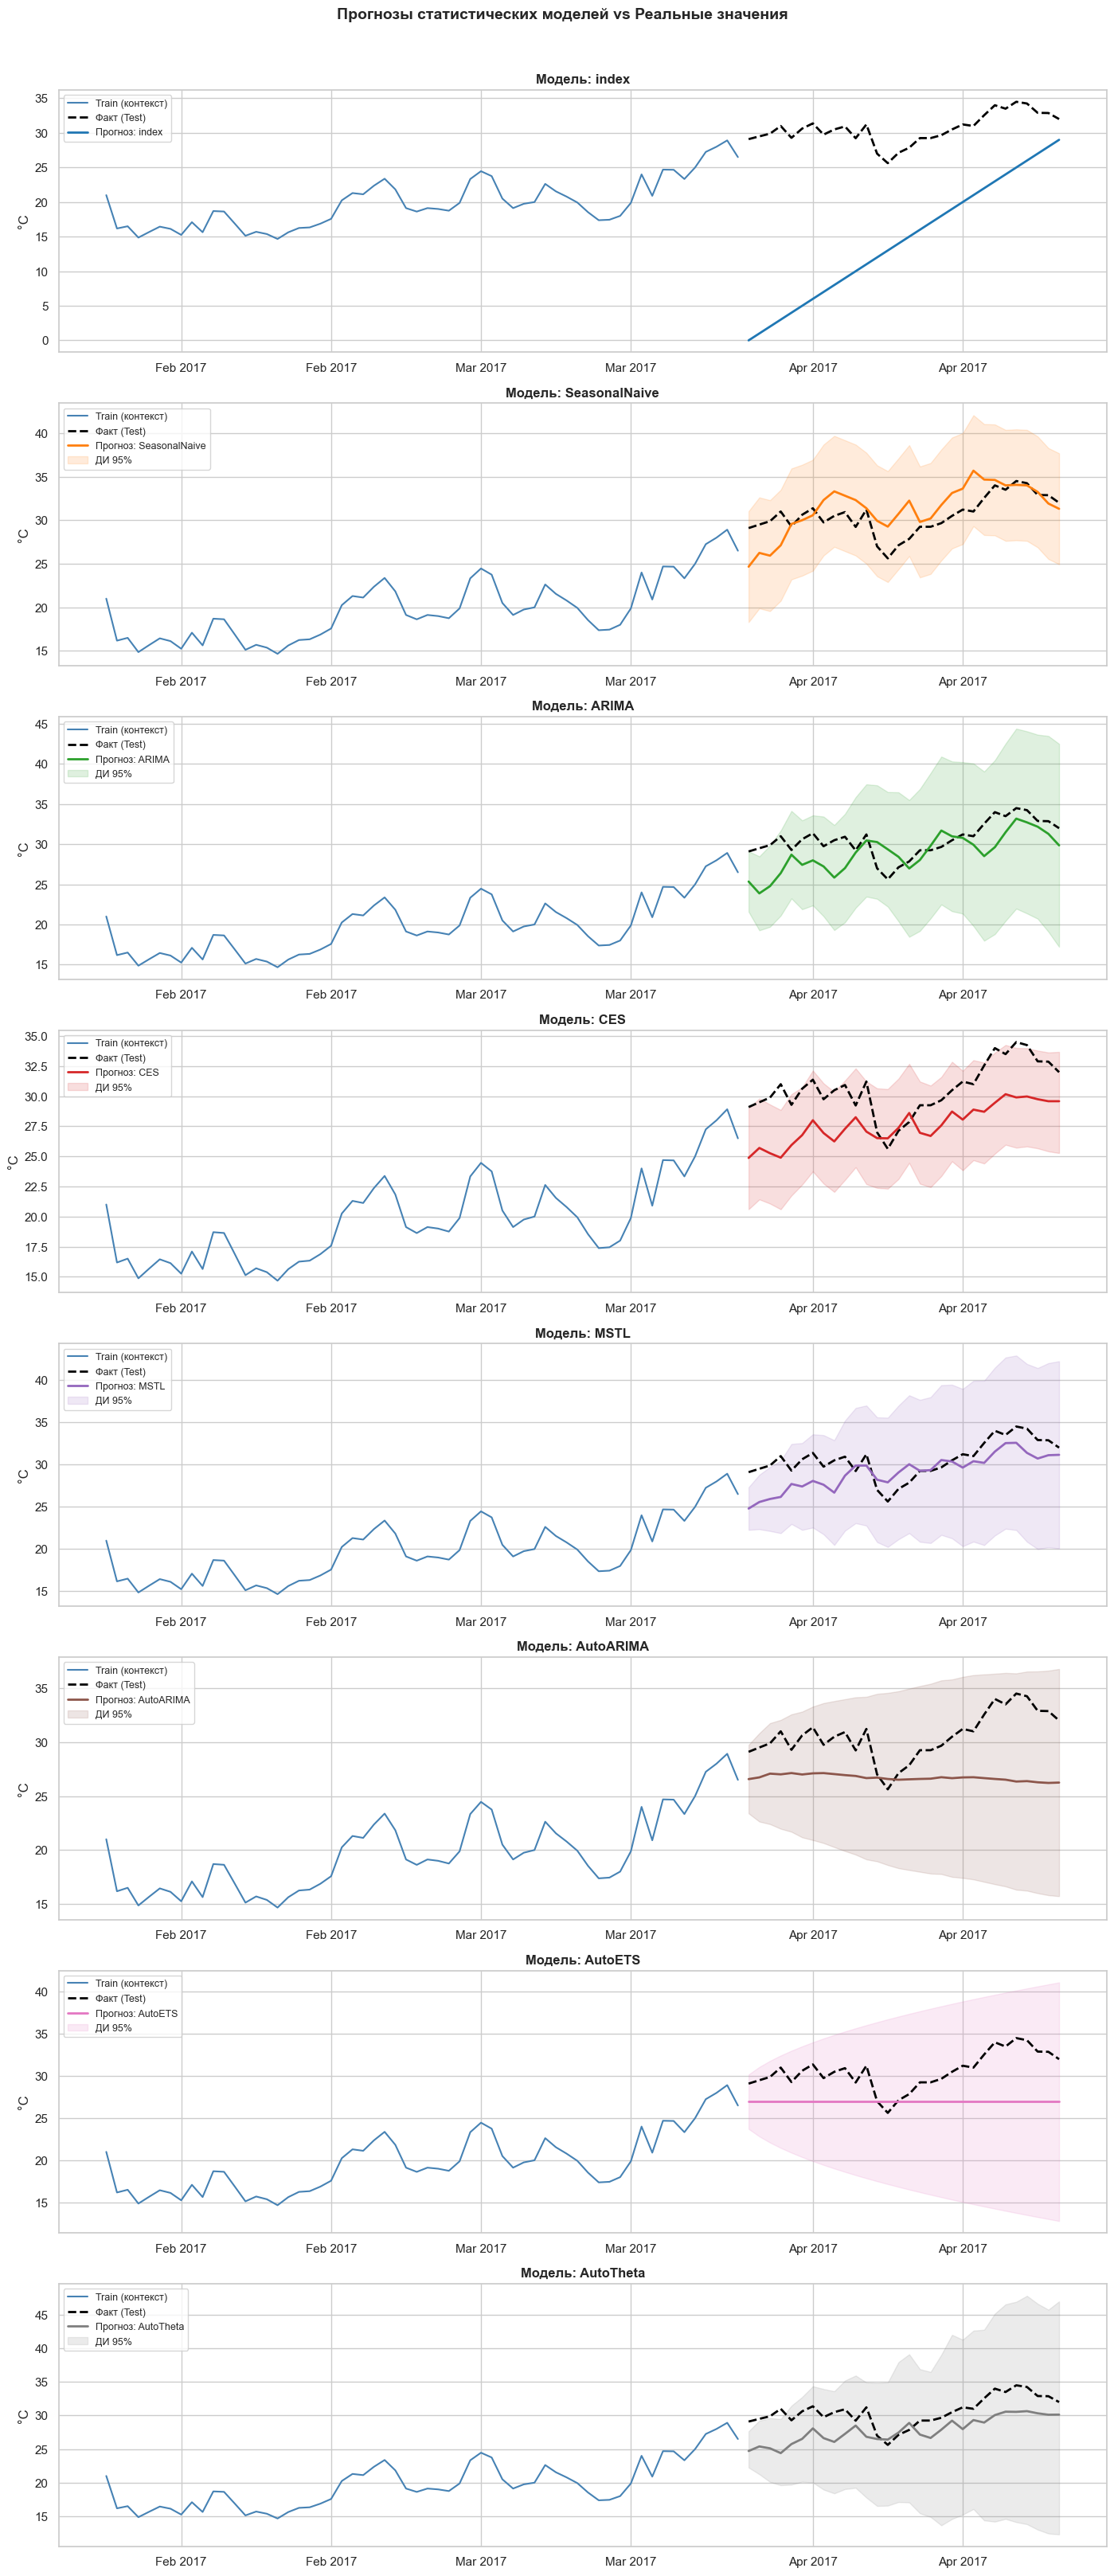

In [12]:
# Определяем список моделей (названия колонок прогноза)
model_cols = [c for c in forecasts_merged.columns 
              if c not in ('unique_id', 'ds', 'actual') 
              and '-lo-' not in c and '-hi-' not in c]

# Последние 60 дней обучающих данных + 30 дней теста
context_days = 60
df_context = df_train.tail(context_days)

fig, axes = plt.subplots(len(model_cols), 1, figsize=(14, 4 * len(model_cols)))

colors = plt.cm.tab10.colors

for i, (col, ax) in enumerate(zip(model_cols, axes)):
    # Контекст (последние 60 дней обучения)
    ax.plot(df_context['ds'], df_context['y'],
            color='steelblue', linewidth=1.5, label='Train (контекст)')
    
    # Реальные значения теста
    ax.plot(forecasts_merged['ds'], forecasts_merged['actual'],
            color='black', linewidth=2, linestyle='--', label='Факт (Test)')
    
    # Прогноз модели
    ax.plot(forecasts_merged['ds'], forecasts_merged[col],
            color=colors[i % len(colors)], linewidth=2, label=f'Прогноз: {col}')
    
    # Доверительный интервал 95% (если есть)
    lo_col = f'{col}-lo-95'
    hi_col = f'{col}-hi-95'
    if lo_col in forecasts_merged.columns and hi_col in forecasts_merged.columns:
        ax.fill_between(forecasts_merged['ds'],
                        forecasts_merged[lo_col],
                        forecasts_merged[hi_col],
                        alpha=0.15, color=colors[i % len(colors)], label='ДИ 95%')
    
    ax.set_title(f'Модель: {col}', fontweight='bold')
    ax.set_ylabel('°C')
    ax.legend(loc='upper left', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.suptitle('Прогнозы статистических моделей vs Реальные значения', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Бектестинг (Temporal Cross-Validation)

Метод скользящего окна для корректной оценки качества моделей на временных рядах.  
Используем **3 окна** (`n_windows=3`) с шагом в `step_size=HORIZON` дней.

In [13]:
# Кросс-валидация (бектестинг)
cv_results = sf.cross_validation(
    df=df_train,
    h=HORIZON,
    n_windows=N_WINDOWS,
    step_size=HORIZON,       # Каждое окно смещается на HORIZON дней
    level=[80, 95]           # Доверительные интервалы
)

print(f'Результаты кросс-валидации: {cv_results.shape}')
cv_results.head(10)

Cross Validation Time Series 1: 100%|██████████| 3/3 [01:21<00:00, 27.31s/it]

Результаты кросс-валидации: (90, 39)


,unique_id,ds,cutoff,y,SeasonalNaive,SeasonalNaive-lo-80,SeasonalNaive-lo-95,SeasonalNaive-hi-80,SeasonalNaive-hi-95,ARIMA,...,AutoETS,AutoETS-lo-95,AutoETS-lo-80,AutoETS-hi-80,AutoETS-hi-95,AutoTheta,AutoTheta-lo-80,AutoTheta-hi-80,AutoTheta-lo-95,AutoTheta-hi-95
0,Delhi_Temperature,2016-12-26,2016-12-25,17.142857,15.375000,11.224918,9.027997,19.525082,21.722003,15.687395,...,14.656894,11.441784,12.554647,16.759142,17.872004,15.563213,14.654057,16.666943,14.353277,17.004226
1,Delhi_Temperature,2016-12-27,2016-12-25,16.850000,17.125000,12.974918,10.777997,21.275082,23.472003,16.551055,...,14.656894,10.573518,11.986918,17.326871,18.740271,15.260348,14.045317,16.475820,13.316502,17.042926
2,Delhi_Temperature,2016-12-28,2016-12-25,17.217391,16.375000,12.224918,10.027997,20.525082,22.722003,15.845738,...,14.656894,9.859917,11.520319,17.793469,19.453872,15.720757,14.023251,17.165333,13.325696,17.889039
3,Delhi_Temperature,2016-12-29,2016-12-25,15.238095,15.500000,11.349918,9.152997,19.650082,21.847003,15.349749,...,14.656894,9.239513,11.114659,18.199130,20.074276,16.349073,14.595812,17.657322,13.932975,18.916148
4,Delhi_Temperature,2016-12-30,2016-12-25,14.095238,15.000000,10.849918,8.652997,19.150082,21.347003,13.572866,...,14.656894,8.683197,10.750904,18.562885,20.630591,17.370617,15.440721,19.206180,14.296351,20.297314
5,Delhi_Temperature,2016-12-31,2016-12-25,15.052632,14.714286,10.564204,8.367283,18.864368,21.061288,15.308016,...,14.656894,8.174450,10.418252,18.895537,21.139339,17.769795,15.552000,20.036540,14.539233,20.894379
6,Delhi_Temperature,2017-01-01,2016-12-25,15.913043,14.000000,9.849918,7.652997,18.150082,20.347003,13.041392,...,14.656894,7.702823,10.109871,19.203918,21.610966,16.522671,14.206148,18.643717,12.947361,19.306092
7,Delhi_Temperature,2017-01-02,2016-12-25,18.500000,14.375000,10.224918,8.027997,18.525082,20.722003,14.758698,...,14.656894,7.261210,9.821116,19.492672,22.052579,17.420947,14.765647,20.249287,13.666330,20.995261
8,Delhi_Temperature,2017-01-03,2016-12-25,17.111111,15.750000,11.599918,9.402997,19.900082,22.097003,16.222947,...,14.656894,6.844521,9.548658,19.765131,22.469268,17.716294,14.838989,20.376989,13.813545,21.561628
9,Delhi_Temperature,2017-01-04,2016-12-25,18.700000,15.833333,11.683251,9.486331,19.983415,22.180336,14.998180,...,14.656894,6.448959,9.290014,20.023775,22.864830,17.482654,14.556355,19.961811,13.533880,21.301214


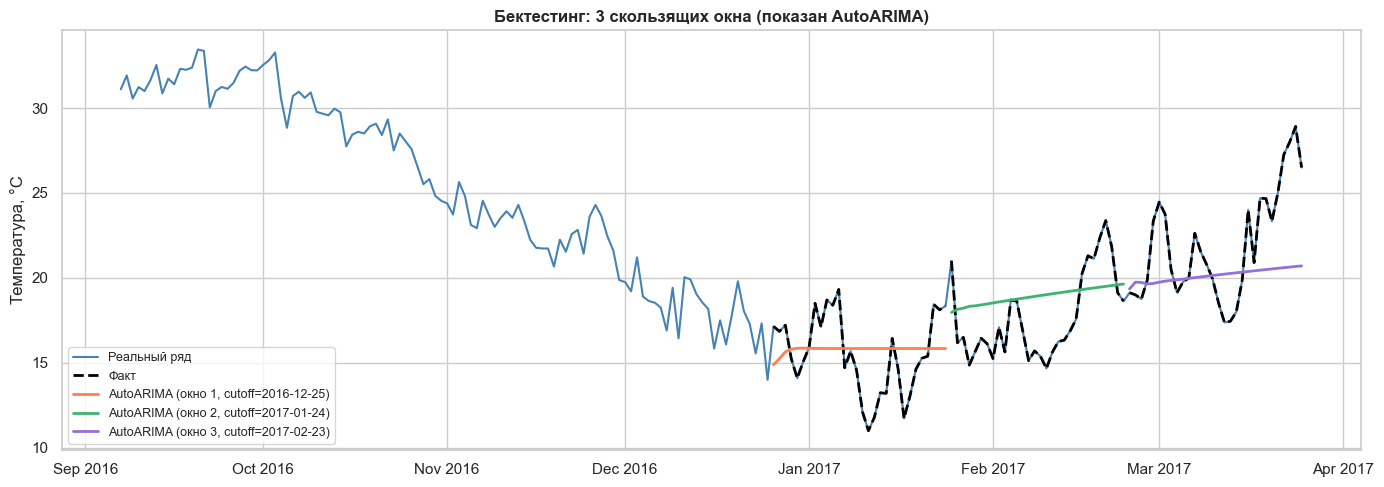

In [14]:
# Визуализация окон бектестинга
cv_plot = cv_results.reset_index()

fig, ax = plt.subplots(figsize=(14, 5))

# Реальный ряд (последние 200 дней для наглядности)
df_tail = df_train.tail(200)
ax.plot(df_tail['ds'], df_tail['y'], color='steelblue', linewidth=1.5, label='Реальный ряд')

# Окна валидации
cutoff_dates = cv_plot['cutoff'].unique()
window_colors = ['coral', 'mediumseagreen', 'mediumpurple']

for j, cutoff in enumerate(cutoff_dates):
    window_data = cv_plot[cv_plot['cutoff'] == cutoff]
    ax.plot(window_data['ds'], window_data['y'], 
            color='black', linewidth=2, linestyle='--',
            label='Факт' if j == 0 else '_nolegend_')
    # Показываем прогноз AutoARIMA как пример
    if 'AutoARIMA' in window_data.columns:
        ax.plot(window_data['ds'], window_data['AutoARIMA'],
                color=window_colors[j % len(window_colors)], linewidth=2,
                label=f'AutoARIMA (окно {j+1}, cutoff={cutoff.strftime("%Y-%m-%d")})')

ax.set_title('Бектестинг: 3 скользящих окна (показан AutoARIMA)', fontweight='bold')
ax.set_ylabel('Температура, °C')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.show()

## Расчет и сравнение метрик качества

In [15]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def compute_metrics(df_cv, model_name, actual_col='y'):
    """Вычисляем MAE и RMSE для модели по всем окнам кросс-валидации."""
    if model_name not in df_cv.columns:
        return None
    valid = df_cv[[actual_col, model_name]].dropna()
    mae  = mean_absolute_error(valid[actual_col], valid[model_name])
    rmse_val = rmse(valid[actual_col], valid[model_name])
    return {'MAE (CV)': round(mae, 4), 'RMSE (CV)': round(rmse_val, 4)}

# CV метрики для каждой модели
cv_df = cv_results.reset_index()
metrics_list = []

for col in model_cols:
    m = compute_metrics(cv_df, col)
    if m:
        m['Модель'] = col
        metrics_list.append(m)

# Test метрики (hold-out)
for col in model_cols:
    if col in forecasts_merged.columns:
        valid = forecasts_merged[['actual', col]].dropna()
        for item in metrics_list:
            if item['Модель'] == col:
                item['MAE (Test)']  = round(mean_absolute_error(valid['actual'], valid[col]), 4)
                item['RMSE (Test)'] = round(rmse(valid['actual'], valid[col]), 4)

metrics_df = pd.DataFrame(metrics_list)[['Модель', 'MAE (CV)', 'RMSE (CV)', 'MAE (Test)', 'RMSE (Test)']]
metrics_df = metrics_df.sort_values('MAE (Test)')

print('=== Сравнительная таблица моделей (сортировка по MAE Test) ===')
metrics_df

=== Сравнительная таблица моделей (сортировка по MAE Test) ===


,Модель,MAE (CV),RMSE (CV),MAE (Test),RMSE (Test)
1,SeasonalNaive,2.6776,3.3628,2.0504,2.5216
4,MSTL,2.8869,3.4313,2.0541,2.4171
2,ARIMA,2.5056,3.2688,2.3671,2.8551
7,AutoTheta,3.9178,4.9603,2.9224,3.2656
3,CES,2.8048,3.3728,3.0324,3.3364
6,AutoETS,2.5382,3.2609,3.7208,4.2132
5,AutoARIMA,2.3262,2.8500,3.9484,4.4786
0,index,29.3176,35.0423,16.0829,17.8277


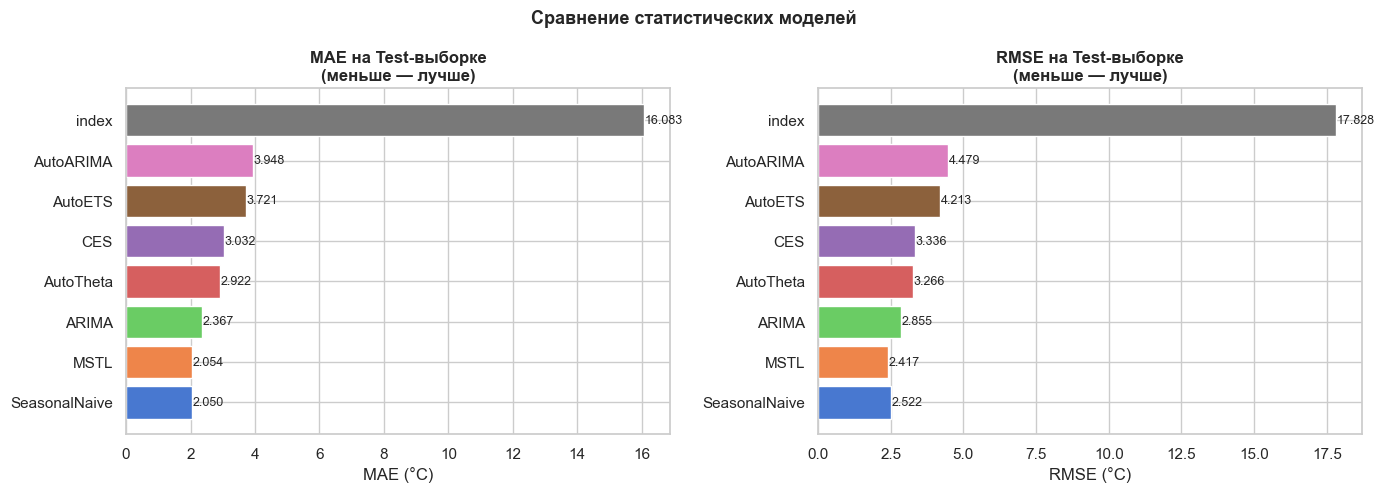

In [16]:
# Визуальное сравнение метрик
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_bar = sns.color_palette('muted', len(metrics_df))

# MAE
axes[0].barh(metrics_df['Модель'], metrics_df['MAE (Test)'], color=colors_bar)
axes[0].set_title('MAE на Test-выборке\n(меньше — лучше)', fontweight='bold')
axes[0].set_xlabel('MAE (°C)')
for i, v in enumerate(metrics_df['MAE (Test)']):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

# RMSE
axes[1].barh(metrics_df['Модель'], metrics_df['RMSE (Test)'], color=colors_bar)
axes[1].set_title('RMSE на Test-выборке\n(меньше — лучше)', fontweight='bold')
axes[1].set_xlabel('RMSE (°C)')
for i, v in enumerate(metrics_df['RMSE (Test)']):
    axes[1].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('Сравнение статистических моделей', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Вероятностное прогнозирование

Анализируем ширину доверительных интервалов и калибровку для лучшей модели.

Лучшая модель по MAE (Test): SeasonalNaive


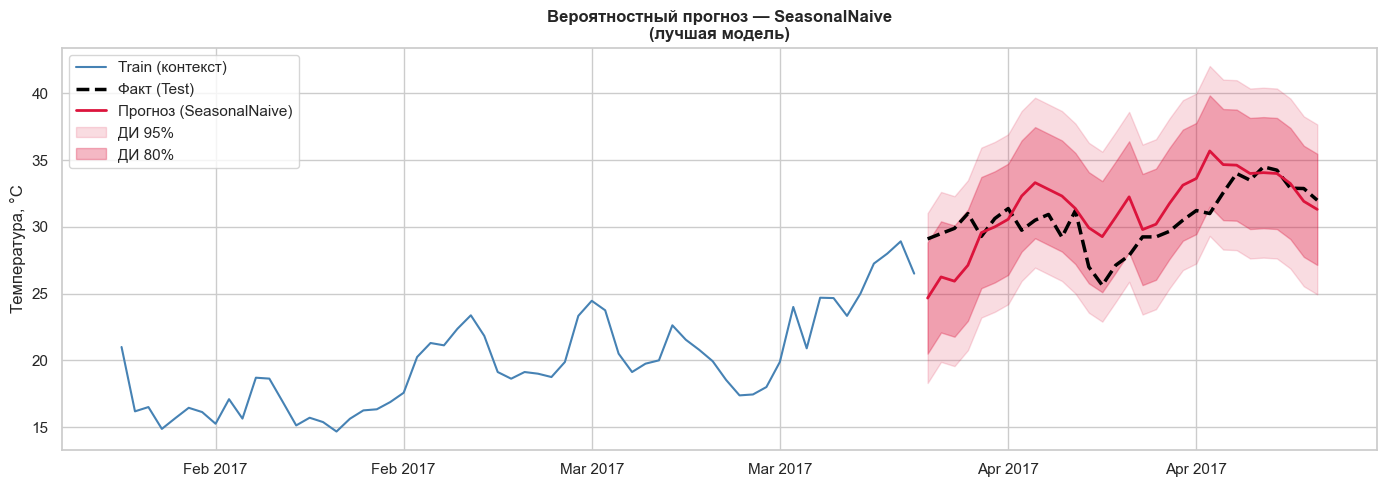


=== Калибровка доверительных интервалов (SeasonalNaive) ===
  ДИ 80%: покрытие = 90.0% (ожидаемое: 80%)
  ДИ 95%: покрытие = 100.0% (ожидаемое: 95%)
  ✅ Интервалы хорошо откалиброваны


In [17]:
# Определяем лучшую модель по MAE Test
best_model = metrics_df.iloc[0]['Модель']
print(f'Лучшая модель по MAE (Test): {best_model}')

# Проверяем наличие интервалов
lo80 = f'{best_model}-lo-80'
hi80 = f'{best_model}-hi-80'
lo95 = f'{best_model}-lo-95'
hi95 = f'{best_model}-hi-95'

has_intervals = all(c in forecasts_merged.columns for c in [lo80, hi80, lo95, hi95])

if has_intervals:
    fig, ax = plt.subplots(figsize=(14, 5))

    # Контекст
    ax.plot(df_train.tail(60)['ds'], df_train.tail(60)['y'],
            color='steelblue', linewidth=1.5, label='Train (контекст)')

    # Факт
    ax.plot(forecasts_merged['ds'], forecasts_merged['actual'],
            color='black', linewidth=2.5, linestyle='--', label='Факт (Test)')

    # Прогноз
    ax.plot(forecasts_merged['ds'], forecasts_merged[best_model],
            color='crimson', linewidth=2, label=f'Прогноз ({best_model})')

    # ДИ 95%
    ax.fill_between(forecasts_merged['ds'],
                    forecasts_merged[lo95], forecasts_merged[hi95],
                    alpha=0.15, color='crimson', label='ДИ 95%')

    # ДИ 80%
    ax.fill_between(forecasts_merged['ds'],
                    forecasts_merged[lo80], forecasts_merged[hi80],
                    alpha=0.3, color='crimson', label='ДИ 80%')

    ax.set_title(f'Вероятностный прогноз — {best_model}\n(лучшая модель)', fontweight='bold')
    ax.set_ylabel('Температура, °C')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.tight_layout()
    plt.show()

    # Калибровка интервалов
    coverage_80 = ((forecasts_merged['actual'] >= forecasts_merged[lo80]) &
                   (forecasts_merged['actual'] <= forecasts_merged[hi80])).mean()
    coverage_95 = ((forecasts_merged['actual'] >= forecasts_merged[lo95]) &
                   (forecasts_merged['actual'] <= forecasts_merged[hi95])).mean()

    print(f'\n=== Калибровка доверительных интервалов ({best_model}) ===')
    print(f'  ДИ 80%: покрытие = {coverage_80:.1%} (ожидаемое: 80%)')
    print(f'  ДИ 95%: покрытие = {coverage_95:.1%} (ожидаемое: 95%)')
    
    if coverage_80 >= 0.75 and coverage_95 >= 0.90:
        print('  ✅ Интервалы хорошо откалиброваны')
    else:
        print('  ⚠️ Интервалы недостаточно точны — модель недооценивает неопределённость')
else:
    print(f'Модель {best_model} не поддерживает вероятностное прогнозирование.')
    # Показываем для AutoETS вместо
    alt_model = 'AutoETS' if 'AutoETS' in model_cols else model_cols[1]
    print(f'Показываем для {alt_model}.')

## Анализ остатков (Residuals Analysis)

Хороший прогноз → остатки должны быть похожи на **белый шум**:  
- Нет автокорреляции (тест Льюнга-Бокса)
- Нормальное распределение  
- Нулевое среднее

In [18]:
# Анализ остатков по результатам кросс-валидации
print('=== Анализ остатков для всех моделей ===')
print()

residuals_dict = {}
for col in model_cols:
    if col in cv_df.columns:
        res = cv_df['y'] - cv_df[col]
        res = res.dropna()
        residuals_dict[col] = res
        
        # Тест Льюнга-Бокса (тест на автокорреляцию)
        lb_test = acorr_ljungbox(res, lags=[10], return_df=True)
        lb_pval = lb_test['lb_pvalue'].values[0]
        
        mean_res = res.mean()
        std_res  = res.std()
        
        white_noise = '✅ белый шум' if lb_pval > 0.05 else '❌ есть автокорреляция'
        zero_mean   = '✅' if abs(mean_res) < 0.5 else '⚠️'
        
        print(f'{col}:')
        print(f'  Среднее остатков: {mean_res:.4f} {zero_mean}')
        print(f'  Std остатков:     {std_res:.4f}')
        print(f'  Тест Льюнга-Бокса (p={lb_pval:.4f}): {white_noise}')
        print()

=== Анализ остатков для всех моделей ===

index:
  Среднее остатков: -26.1289 ⚠️
  Std остатков:     23.4813
  Тест Льюнга-Бокса (p=0.0000): ❌ есть автокорреляция

SeasonalNaive:
  Среднее остатков: -0.8914 ⚠️
  Std остатков:     3.2606
  Тест Льюнга-Бокса (p=0.0000): ❌ есть автокорреляция

ARIMA:
  Среднее остатков: 1.3427 ⚠️
  Std остатков:     2.9970
  Тест Льюнга-Бокса (p=0.0000): ❌ есть автокорреляция

CES:
  Среднее остатков: -0.9430 ⚠️
  Std остатков:     3.2564
  Тест Льюнга-Бокса (p=0.0000): ❌ есть автокорреляция

MSTL:
  Среднее остатков: -1.5910 ⚠️
  Std остатков:     3.0571
  Тест Льюнга-Бокса (p=0.0000): ❌ есть автокорреляция

AutoARIMA:
  Среднее остатков: 0.0925 ✅
  Std остатков:     2.8644
  Тест Льюнга-Бокса (p=0.0000): ❌ есть автокорреляция

AutoETS:
  Среднее остатков: 1.1024 ⚠️
  Std остатков:     3.0861
  Тест Льюнга-Бокса (p=0.0000): ❌ есть автокорреляция

AutoTheta:
  Среднее остатков: -2.3670 ⚠️
  Std остатков:     4.3836
  Тест Льюнга-Бокса (p=0.0000): ❌ есть а

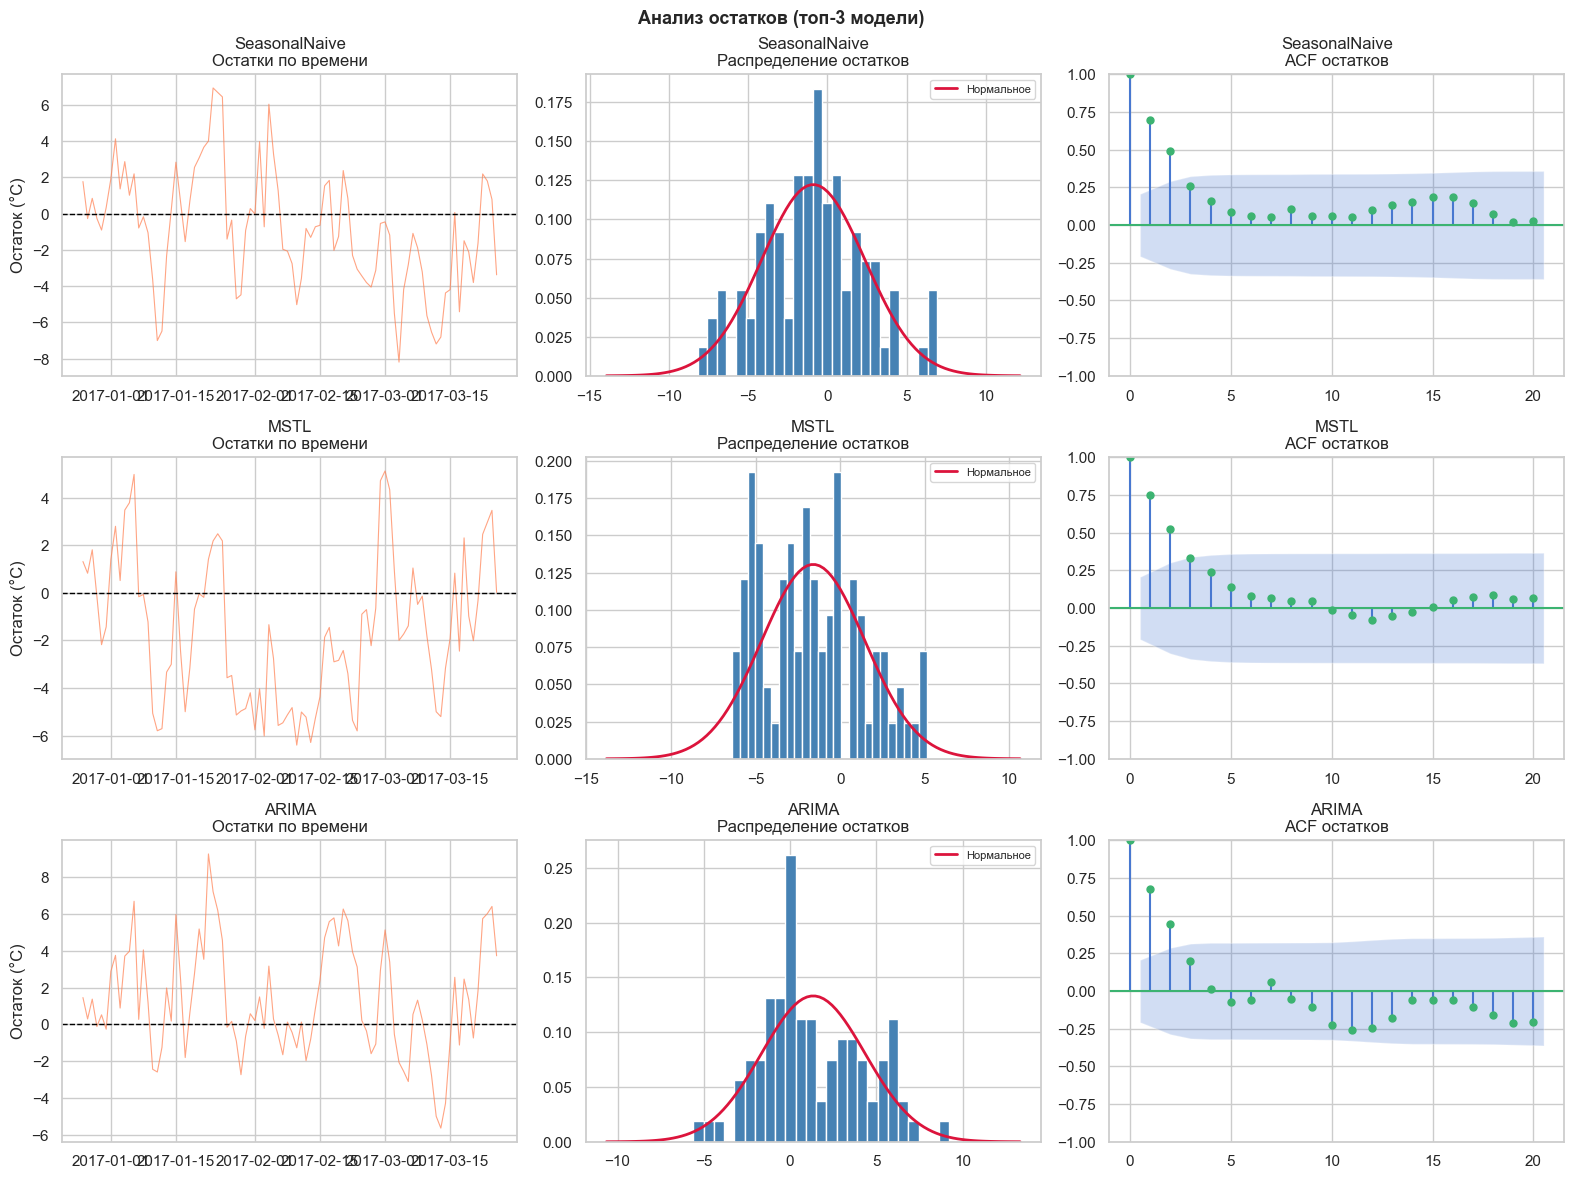

In [19]:
# Визуализация остатков лучших 3 моделей
top3_models = metrics_df.head(3)['Модель'].tolist()
top3_models = [m for m in top3_models if m in residuals_dict]

fig, axes = plt.subplots(len(top3_models), 3, figsize=(16, 4 * len(top3_models)))
if len(top3_models) == 1:
    axes = [axes]

for i, model_name in enumerate(top3_models):
    res = residuals_dict[model_name]
    
    # 1. Временной ряд остатков
    axes[i][0].plot(cv_df['ds'].iloc[:len(res)], res.values, 
                    color='coral', alpha=0.7, linewidth=0.8)
    axes[i][0].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[i][0].set_title(f'{model_name}\nОстатки по времени')
    axes[i][0].set_ylabel('Остаток (°C)')
    
    # 2. Гистограмма остатков
    axes[i][1].hist(res, bins=25, color='steelblue', edgecolor='white', density=True)
    # Нормальная кривая
    mu, sigma = res.mean(), res.std()
    x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
    axes[i][1].plot(x, 1/(sigma*np.sqrt(2*np.pi)) * np.exp(-0.5*((x-mu)/sigma)**2),
                    color='crimson', linewidth=2, label='Нормальное')
    axes[i][1].set_title(f'{model_name}\nРаспределение остатков')
    axes[i][1].legend(fontsize=8)
    
    # 3. ACF остатков
    plot_acf(res, lags=20, ax=axes[i][2], color='mediumseagreen')
    axes[i][2].set_title(f'{model_name}\nACF остатков')

plt.suptitle('Анализ остатков (топ-3 модели)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Итоговая таблица сравнения моделей

In [20]:
# Дополняем таблицу описательной информацией
model_info = {
    'SeasonalNaive':    {'Тип': 'Базовая линия', 'Режим': 'ручной', 'Параметров': 1},
    'ARIMA':            {'Тип': 'ARIMA', 'Режим': 'ручной (p=2,d=1,q=2)', 'Параметров': 6},
    'CES':              {'Тип': 'Complex Exp. Smoothing', 'Режим': 'ручной', 'Параметров': 2},
    'MSTL':             {'Тип': 'Multi-Seasonal Decomp.', 'Режим': 'ручной [7, 365]', 'Параметров': 3},
    'AutoARIMA':        {'Тип': 'ARIMA', 'Режим': 'авто', 'Параметров': 'подбирается'},
    'AutoETS':          {'Тип': 'Exp. Smoothing', 'Режим': 'авто', 'Параметров': 'подбирается'},
    'AutoTheta':        {'Тип': 'Theta', 'Режим': 'авто', 'Параметров': 'подбирается'},
}

# Добавляем тест белого шума
lb_results = {}
for col in model_cols:
    if col in residuals_dict:
        lb_test = acorr_ljungbox(residuals_dict[col], lags=[10], return_df=True)
        lb_results[col] = 'Да' if lb_test['lb_pvalue'].values[0] > 0.05 else 'Нет'

# Собираем итоговую таблицу
final_rows = []
for _, row in metrics_df.iterrows():
    model = row['Модель']
    info = model_info.get(model, {'Тип': '—', 'Режим': '—', 'Параметров': '—'})
    final_rows.append({
        'Модель': model,
        'Тип': info['Тип'],
        'Режим': info['Режим'],
        'MAE (CV)': row['MAE (CV)'],
        'RMSE (CV)': row['RMSE (CV)'],
        'MAE (Test)': row['MAE (Test)'],
        'RMSE (Test)': row['RMSE (Test)'],
        'Белый шум (LB)': lb_results.get(model, '—'),
    })

final_table = pd.DataFrame(final_rows)

print('=== ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ ===')
print('(отсортировано по MAE на Test-выборке)')
print()
print(final_table.to_string(index=False))

=== ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ ===
(отсортировано по MAE на Test-выборке)

       Модель                    Тип                Режим  MAE (CV)  RMSE (CV)  MAE (Test)  RMSE (Test) Белый шум (LB)
SeasonalNaive          Базовая линия               ручной    2.6776     3.3628      2.0504       2.5216            Нет
         MSTL Multi-Seasonal Decomp.      ручной [7, 365]    2.8869     3.4313      2.0541       2.4171            Нет
        ARIMA                  ARIMA ручной (p=2,d=1,q=2)    2.5056     3.2688      2.3671       2.8551            Нет
    AutoTheta                  Theta                 авто    3.9178     4.9603      2.9224       3.2656            Нет
          CES Complex Exp. Smoothing               ручной    2.8048     3.3728      3.0324       3.3364            Нет
      AutoETS         Exp. Smoothing                 авто    2.5382     3.2609      3.7208       4.2132            Нет
    AutoARIMA                  ARIMA                 авто    2.3262     2.8500      

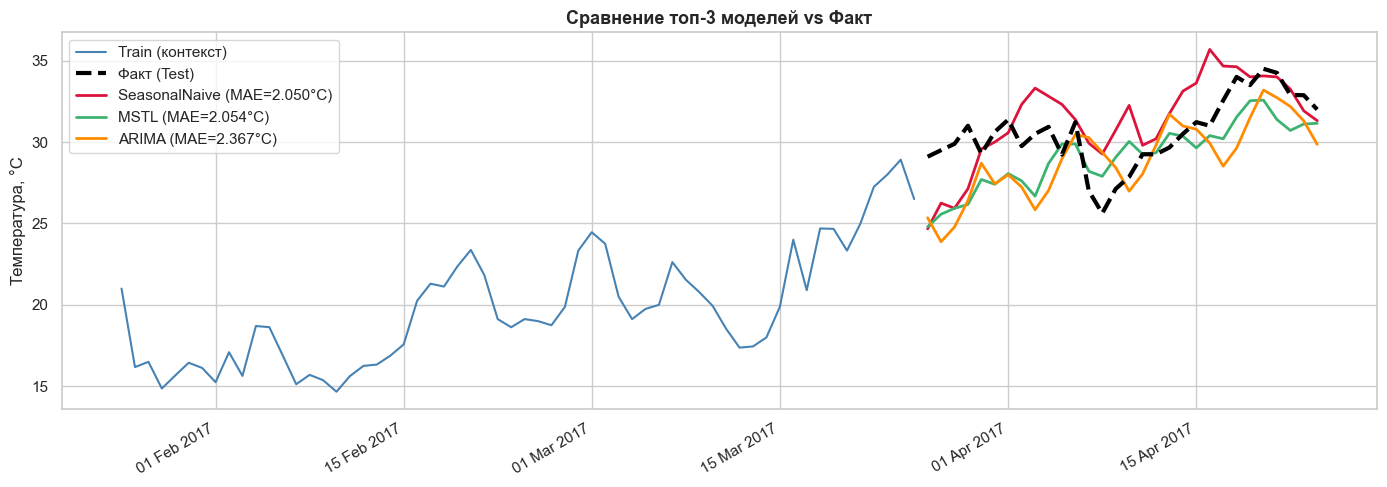

In [21]:
# Финальное визуальное сравнение лучших прогнозов
top3 = metrics_df.head(3)['Модель'].tolist()

plt.figure(figsize=(14, 5))

# Контекст
plt.plot(df_train.tail(60)['ds'], df_train.tail(60)['y'],
         color='steelblue', linewidth=1.5, label='Train (контекст)')

# Факт
plt.plot(forecasts_merged['ds'], forecasts_merged['actual'],
         color='black', linewidth=3, linestyle='--', label='Факт (Test)', zorder=10)

# Прогнозы топ-3 моделей
colors_top = ['crimson', 'mediumseagreen', 'darkorange']
for col, c in zip(top3, colors_top):
    if col in forecasts_merged.columns:
        mae_val = metrics_df[metrics_df['Модель'] == col]['MAE (Test)'].values[0]
        plt.plot(forecasts_merged['ds'], forecasts_merged[col],
                 color=c, linewidth=2, label=f'{col} (MAE={mae_val:.3f}°C)')

plt.title('Сравнение топ-3 моделей vs Факт', fontsize=13, fontweight='bold')
plt.ylabel('Температура, °C')
plt.legend()
plt.xaxis = plt.gca().xaxis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

In [24]:
# Сохранение лучшего прогноза и результатов CV для Задачи №3
cv_results.to_csv('Task2_CV_Results.csv')
forecasts.to_csv('Task2_Forecasts.csv')
final_table.to_csv('Task2_Comparison_Table.csv', index=False)

print('Файлы сохранены:')
print('  Task2_CV_Results.csv       — результаты бектестинга')
print('  Task2_Forecasts.csv        — прогнозы на test')
print('  Task2_Comparison_Table.csv — итоговая таблица')
print()
print(f'Лучшая модель: {metrics_df.iloc[1]["Модель"]}')
print(f'  MAE (Test):  {metrics_df.iloc[1]["MAE (Test)"]} °C')
print(f'  RMSE (Test): {metrics_df.iloc[1]["RMSE (Test)"]} °C')

Файлы сохранены:
  Task2_CV_Results.csv       — результаты бектестинга
  Task2_Forecasts.csv        — прогнозы на test
  Task2_Comparison_Table.csv — итоговая таблица

Лучшая модель: MSTL
  MAE (Test):  2.0541 °C
  RMSE (Test): 2.4171 °C
